# Coefficient Correlation Heatmaps: Interactions & Single Ligands

Streamlined companion viz to the HDBSCAN bootstrap notebooks (`01_hdbscan_bootstrap_interactions.ipynb`, `02_hdbscan_bootstrap_singleLigand.ipynb`). These heatmaps plot the Pearson correlation of GLM coefficient profiles between conditions, using the same top-variable-gene selection and consistent-ligand filtering as those notebooks, then annotates rows by their `min_samples=1` HDBSCAN reference cluster assignment.

For each coefficient type (interactions, single ligands) two heatmaps are produced:
1. **Full** — every consistent interaction / linker-containing condition, cluster-annotated (noise = grey).
2. **Clustered-only** — the same correlation values, subset to conditions assigned to a real HDBSCAN cluster (noise excluded).

# Import

In [21]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

mpl.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

In [22]:
def rename_linker_condition(condition):
    if condition.startswith('linker_'):
        return f"{condition[len('linker_'):]}_SetB"
    elif condition.endswith('_linker'):
        return f"{condition[:-len('_linker')]}_SetA"
    else:
        return condition

In [23]:
base_dir = f'{IMPORTS_DIR}/SIG13/analysis_outs'  # upstream inputs
out_dir = OUTS_DIR  # outputs of this notebook
plots_dir = f'{out_dir}/clustering/plots'
os.makedirs(plots_dir, exist_ok=True)

REF_FILTER = '0.2filter'
REF_N_GENES_INTERACTION = 500
REF_N_GENES_SINGLE = 3000

# Consistent-ligand filter for interactions (same criterion as the bootstrap notebooks)
interRepCor = pd.read_csv(f'{base_dir}/replicate_corr/replicate_correlation_interactionLfc_0.2filter.csv')
consistent_ligands = interRepCor[
    (interRepCor['pearson_corr'] > 0.25) & (interRepCor['num_shared_genes'] > 1)
]['interaction'].tolist()
print(f'Consistent ligands: {len(consistent_ligands)}')

# Consistent-condition filter for single ligands (same criterion, from the 02 bootstrap notebook)
singleRepCor = pd.read_csv(f'{base_dir}/replicate_corr/replicate_correlation_singleLfc_0.2filter.csv')
consistent_single_ligands = singleRepCor[
    (singleRepCor['pearson_corr'] > 0.25) & (singleRepCor['num_shared_genes'] > 1)
]['condition'].tolist()
print(f'Consistent single ligands: {len(consistent_single_ligands)}')

# Coefficient tables
interaction_coeff = pd.read_csv(f'{base_dir}/glmGamPoi/glmGamPoi_interaction/glmGamPoi_coefficients_{REF_FILTER}.csv')
single_coeff = pd.read_csv(f'{base_dir}/glmGamPoi/glmGamPoi_single_term/glmGamPoi_coefficients_{REF_FILTER}.csv')
print(f'Interaction coefficients: {interaction_coeff.shape}')
print(f'Single-term coefficients: {single_coeff.shape}')

# HVG-selection sources (same files used by the bootstrap notebooks)
interaction_scored = pd.read_csv(f'{base_dir}/glmGamPoi/interactions_scored_v3_glmGamPoi_{REF_FILTER}_sig.csv')
single_sigLfc = pd.read_csv(f'{base_dir}/glmGamPoi/glmGamPoi_single_term/glmGamPoi_singleTerm_lfc_sig_{REF_FILTER}.csv')
print(f'Interactions scored (HVG source): {interaction_scored.shape}')
print(f'Single-term sig LFC (HVG source): {single_sigLfc.shape}')

# HDBSCAN reference cluster assignments (min_samples=1), from the bootstrap notebooks
interaction_clusters = pd.read_csv(
    f'{base_dir}/clustering/hdbscan_bootstrap_modal_clusters_minSamples1.csv'
).set_index('interaction')['cluster']
single_clusters = pd.read_csv(
    f'{base_dir}/clustering/hdbscan_bootstrap_modal_clusters_singleLigand_minSamples1.csv'
).set_index('condition')['cluster']
single_clusters.index = single_clusters.index.map(rename_linker_condition)
print(f'Interaction clusters: {(interaction_clusters != -1).sum()} clustered / {len(interaction_clusters)} total')
print(f'Single-ligand clusters: {(single_clusters != -1).sum()} clustered / {len(single_clusters)} total')

# Number of significant interaction effects per condition, split by interaction_class
# (buffering / synergy positive / synergy negative), plus significant DEGs for single ligands.
# These feed log10-scaled numeric row-color annotations below.
interaction_buffering_counts = (
    interaction_scored[interaction_scored['interaction_class'] == 'buffering']
    .groupby('interaction').size()
)
interaction_synergy_pos_counts = (
    interaction_scored[interaction_scored['interaction_class'] == 'synergy positive']
    .groupby('interaction').size()
)
interaction_synergy_neg_counts = (
    interaction_scored[interaction_scored['interaction_class'] == 'synergy negative']
    .groupby('interaction').size()
)
single_sig_counts = (
    single_sigLfc[single_sigLfc['condition'].astype(str).str.contains('linker', case=False, na=False)]
    .groupby('condition')
    .size()
)
single_sig_counts.index = single_sig_counts.index.map(rename_linker_condition)
print(f'Buffering counts: n={len(interaction_buffering_counts)}, median={interaction_buffering_counts.median():.0f}')
print(f'Synergy positive counts: n={len(interaction_synergy_pos_counts)}, median={interaction_synergy_pos_counts.median():.0f}')
print(f'Synergy negative counts: n={len(interaction_synergy_neg_counts)}, median={interaction_synergy_neg_counts.median():.0f}')
print(f'Single-ligand sig-DEG counts: n={len(single_sig_counts)}, median={single_sig_counts.median():.0f}')

Consistent ligands: 146
Consistent single ligands: 561
Interaction coefficients: (3794990, 11)
Single-term coefficients: (4204160, 9)
Interactions scored (HVG source): (1565086, 13)
Single-term sig LFC (HVG source): (1548490, 8)
Interaction clusters: 107 clustered / 146 total
Single-ligand clusters: 31 clustered / 38 total
Buffering counts: n=407, median=4
Synergy positive counts: n=320, median=7
Synergy negative counts: n=375, median=6
Single-ligand sig-DEG counts: n=65, median=37


## Helper Functions

In [24]:
def build_wide_mat_interaction(coeff_df, interScored_df, consistent_ligands, n_genes, lfc_col='ligand1:ligand2'):
    """Pivot interaction coefficient df to (interactions x genes), using the top n_genes by
    variance of lfc_interaction in the interactions_scored file (consistent ligands only)."""
    genes_selected = (
        interScored_df
        .loc[interScored_df['interaction'].isin(consistent_ligands)]
        .groupby('name')['lfc_interaction']
        .var()
        .nlargest(n_genes)
        .index.tolist()
    )
    df = coeff_df[coeff_df['interaction'].isin(consistent_ligands)].copy()
    df = df[df['genes'].isin(genes_selected)]
    return df.pivot_table(index='interaction', columns='genes', values=lfc_col, fill_value=0)


def build_wide_mat_single(coeff_df, sigLfc_df, n_genes, consistent_ligands, lfc_col='ligand'):
    """Pivot single-term coefficient df to (conditions x genes), using the top n_genes by
    variance of lfc in the significant single-term LFC file, restricted to linker-containing,
    replicate-consistent conditions (same consistency criterion as the 02 bootstrap notebook)."""
    genes_selected = (
        sigLfc_df
        .loc[sigLfc_df['condition'].astype(str).str.contains('linker', case=False, na=False)]
        .loc[sigLfc_df['condition'].isin(consistent_ligands)]
        .groupby('name')['lfc']
        .var()
        .nlargest(n_genes)
        .index.tolist()
    )
    df = coeff_df[coeff_df['condition'].astype(str).str.contains('linker', case=False, na=False)].copy()
    df = df[df['condition'].isin(consistent_ligands)]
    df = df[df['name'].isin(genes_selected)]
    return df.pivot_table(index='condition', columns='name', values=lfc_col, fill_value=0)


def coeff_corr_matrix(wide_mat, method='pearson'):
    """Pairwise correlation between conditions/interactions based on their coefficient profile across genes."""
    return wide_mat.T.corr(method=method)


def build_cluster_row_colors(index_labels, cluster_series, noise_color='lightgrey', palette='tab20'):
    """Map each label to a color by HDBSCAN cluster id (noise/-1 -> noise_color). Returns (row_colors, legend_handles)."""
    clusters = cluster_series.reindex(index_labels)
    unique_clusters = sorted(c for c in clusters.unique() if c != -1)
    colors = sns.color_palette(palette, max(len(unique_clusters), 1))
    color_map = {c: mcolors.to_hex(colors[i]) for i, c in enumerate(unique_clusters)}
    color_map[-1] = noise_color

    row_colors = clusters.map(color_map)
    row_colors.name = 'cluster'

    legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[c], label=f'cluster {c}') for c in unique_clusters]
    if -1 in clusters.values:
        legend_handles.append(plt.Rectangle((0, 0), 1, 1, color=noise_color, label='noise'))
    return row_colors, legend_handles


def build_numeric_row_colors(index_labels, count_series, cmap='viridis', label='n_sig', log10=True, vmin=None, vmax=None):
    """Map each label to a color via a continuous colormap based on a numeric count series
    (e.g. number of significant interaction effects or DEGs). Labels missing from count_series
    are treated as a count of 0. If log10 is True (default), colors/normalization are based on
    log10(count + 1) rather than the raw count. vmin/vmax can be passed explicitly (e.g. to share
    a common color range across multiple annotations) instead of being derived from this series
    alone. Returns (row_colors, norm, cmap_obj) for building a matching colorbar."""
    counts = count_series.reindex(index_labels).fillna(0)
    values = np.log10(counts + 1) if log10 else counts
    norm = mcolors.Normalize(
        vmin=vmin if vmin is not None else np.nanmin(values.values),
        vmax=vmax if vmax is not None else np.nanmax(values.values),
    )
    cmap_obj = plt.get_cmap(cmap)
    row_colors = values.apply(lambda v: mcolors.to_hex(cmap_obj(norm(v))) if pd.notna(v) else '#ffffff')
    row_colors.name = label
    return row_colors, norm, cmap_obj


def plot_heatmap_anno(corr_matrix,
                 row_colors=None,
                 legend_handles=None,
                 numeric_cbars=None,
                 title='Heatmap',
                 xlabel='Pearson\ncorr',
                 cmap='RdBu_r',
                 method='ward',
                 vmax=1,
                 vmin=-1,
                 width=12,
                 height=10,
                 xticklabels=True,
                 yticklabels=True,
                 save_path=None,
                 save_dpi=150):
    """
    Plots a customizable heatmap with clustering and optional row-color annotations.
    Reused from ligand_clustering_corr.ipynb's "Interaction Coefficient Clustering" section
    (cmap='RdBu_r'), with an added save_path option.

    Parameters:
    -----------
    corr_matrix : pd.DataFrame
        Square data matrix (e.g. a correlation matrix) to cluster & plot.
    row_colors : pd.Series, list, or pd.DataFrame, optional
        Colors to annotate each row. Must align with corr_matrix.index.
    legend_handles : list of matplotlib.patches.Patch, optional
        Prebuilt legend handles (with .label set) for your annotation.
    numeric_cbars : list of dict, optional
        Each dict is {'norm': Normalize, 'cmap': Colormap or name, 'label': str} describing a
        continuous row-color annotation (e.g. from build_numeric_row_colors). Draws one matching
        colorbar per dict, stacked below the main correlation colorbar.
    title : str
        Plot title.
    xlabel : str
        Label for the colorbar.
    cmap : str
        Matplotlib colormap name.
    method : str
        Clustering method (e.g. 'ward', 'average', etc).
    vmax, vmin : float
        Color scale limits.
    width, height : float
        Figure size in inches.
    save_path : str, optional
        If given, saves the figure to this PNG path and to a companion PDF
        (same basename, .pdf extension) using the notebook's pdf.fonttype=42 setting.
    save_dpi : int
        DPI used when saving the PNG (kept well below the notebook's savefig.dpi=300
        default so large matrices don't blow up into multi-hundred-megapixel files).
    """
    g = sns.clustermap(
        corr_matrix,
        row_colors=row_colors,
        annot=False,
        cmap=cmap,
        method=method,
        vmax=vmax,
        vmin=vmin,
        dendrogram_ratio=(.1, 0),
        xticklabels=xticklabels,
        yticklabels=yticklabels,
        cbar_kws={'orientation': 'vertical', 'shrink': 0.2},
        figsize=(width, height)
    )

    g.cax.set_position([1.03, 0.1, .03, .2])
    g.cax.set_xlabel(xlabel, fontsize=10)
    g.cax.xaxis.set_label_position('top')

    g.ax_heatmap.set_xlabel("")
    g.ax_heatmap.set_ylabel("")
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=9)
    g.ax_heatmap.set_title(title, fontsize=20)

    if legend_handles is not None:
        g.ax_heatmap.legend(
            handles=legend_handles,
            bbox_to_anchor=(1.1, 1),
            bbox_transform=g.ax_heatmap.transAxes,
            loc='upper left',
            title='Cluster'
        )

    if numeric_cbars is not None:
        for i, cbar_spec in enumerate(numeric_cbars):
            numeric_cax = g.fig.add_axes([1.03, 0.35 + i * 0.27, .03, .2])
            sm = plt.cm.ScalarMappable(norm=cbar_spec['norm'], cmap=cbar_spec['cmap'])
            sm.set_array([])
            numeric_cb = g.fig.colorbar(sm, cax=numeric_cax)
            numeric_cb.ax.set_xlabel(cbar_spec['label'], fontsize=10)
            numeric_cb.ax.xaxis.set_label_position('top')

    if save_path is not None:
        g.savefig(save_path, bbox_inches='tight', dpi=save_dpi)

    plt.show()
    return g

## Interaction Coefficient Correlation

In [25]:
interaction_wide_mat = build_wide_mat_interaction(interaction_coeff, interaction_scored, consistent_ligands, REF_N_GENES_INTERACTION)
interaction_corr = coeff_corr_matrix(interaction_wide_mat)
print(f'Interaction correlation matrix: {interaction_corr.shape}')

Interaction correlation matrix: (146, 146)


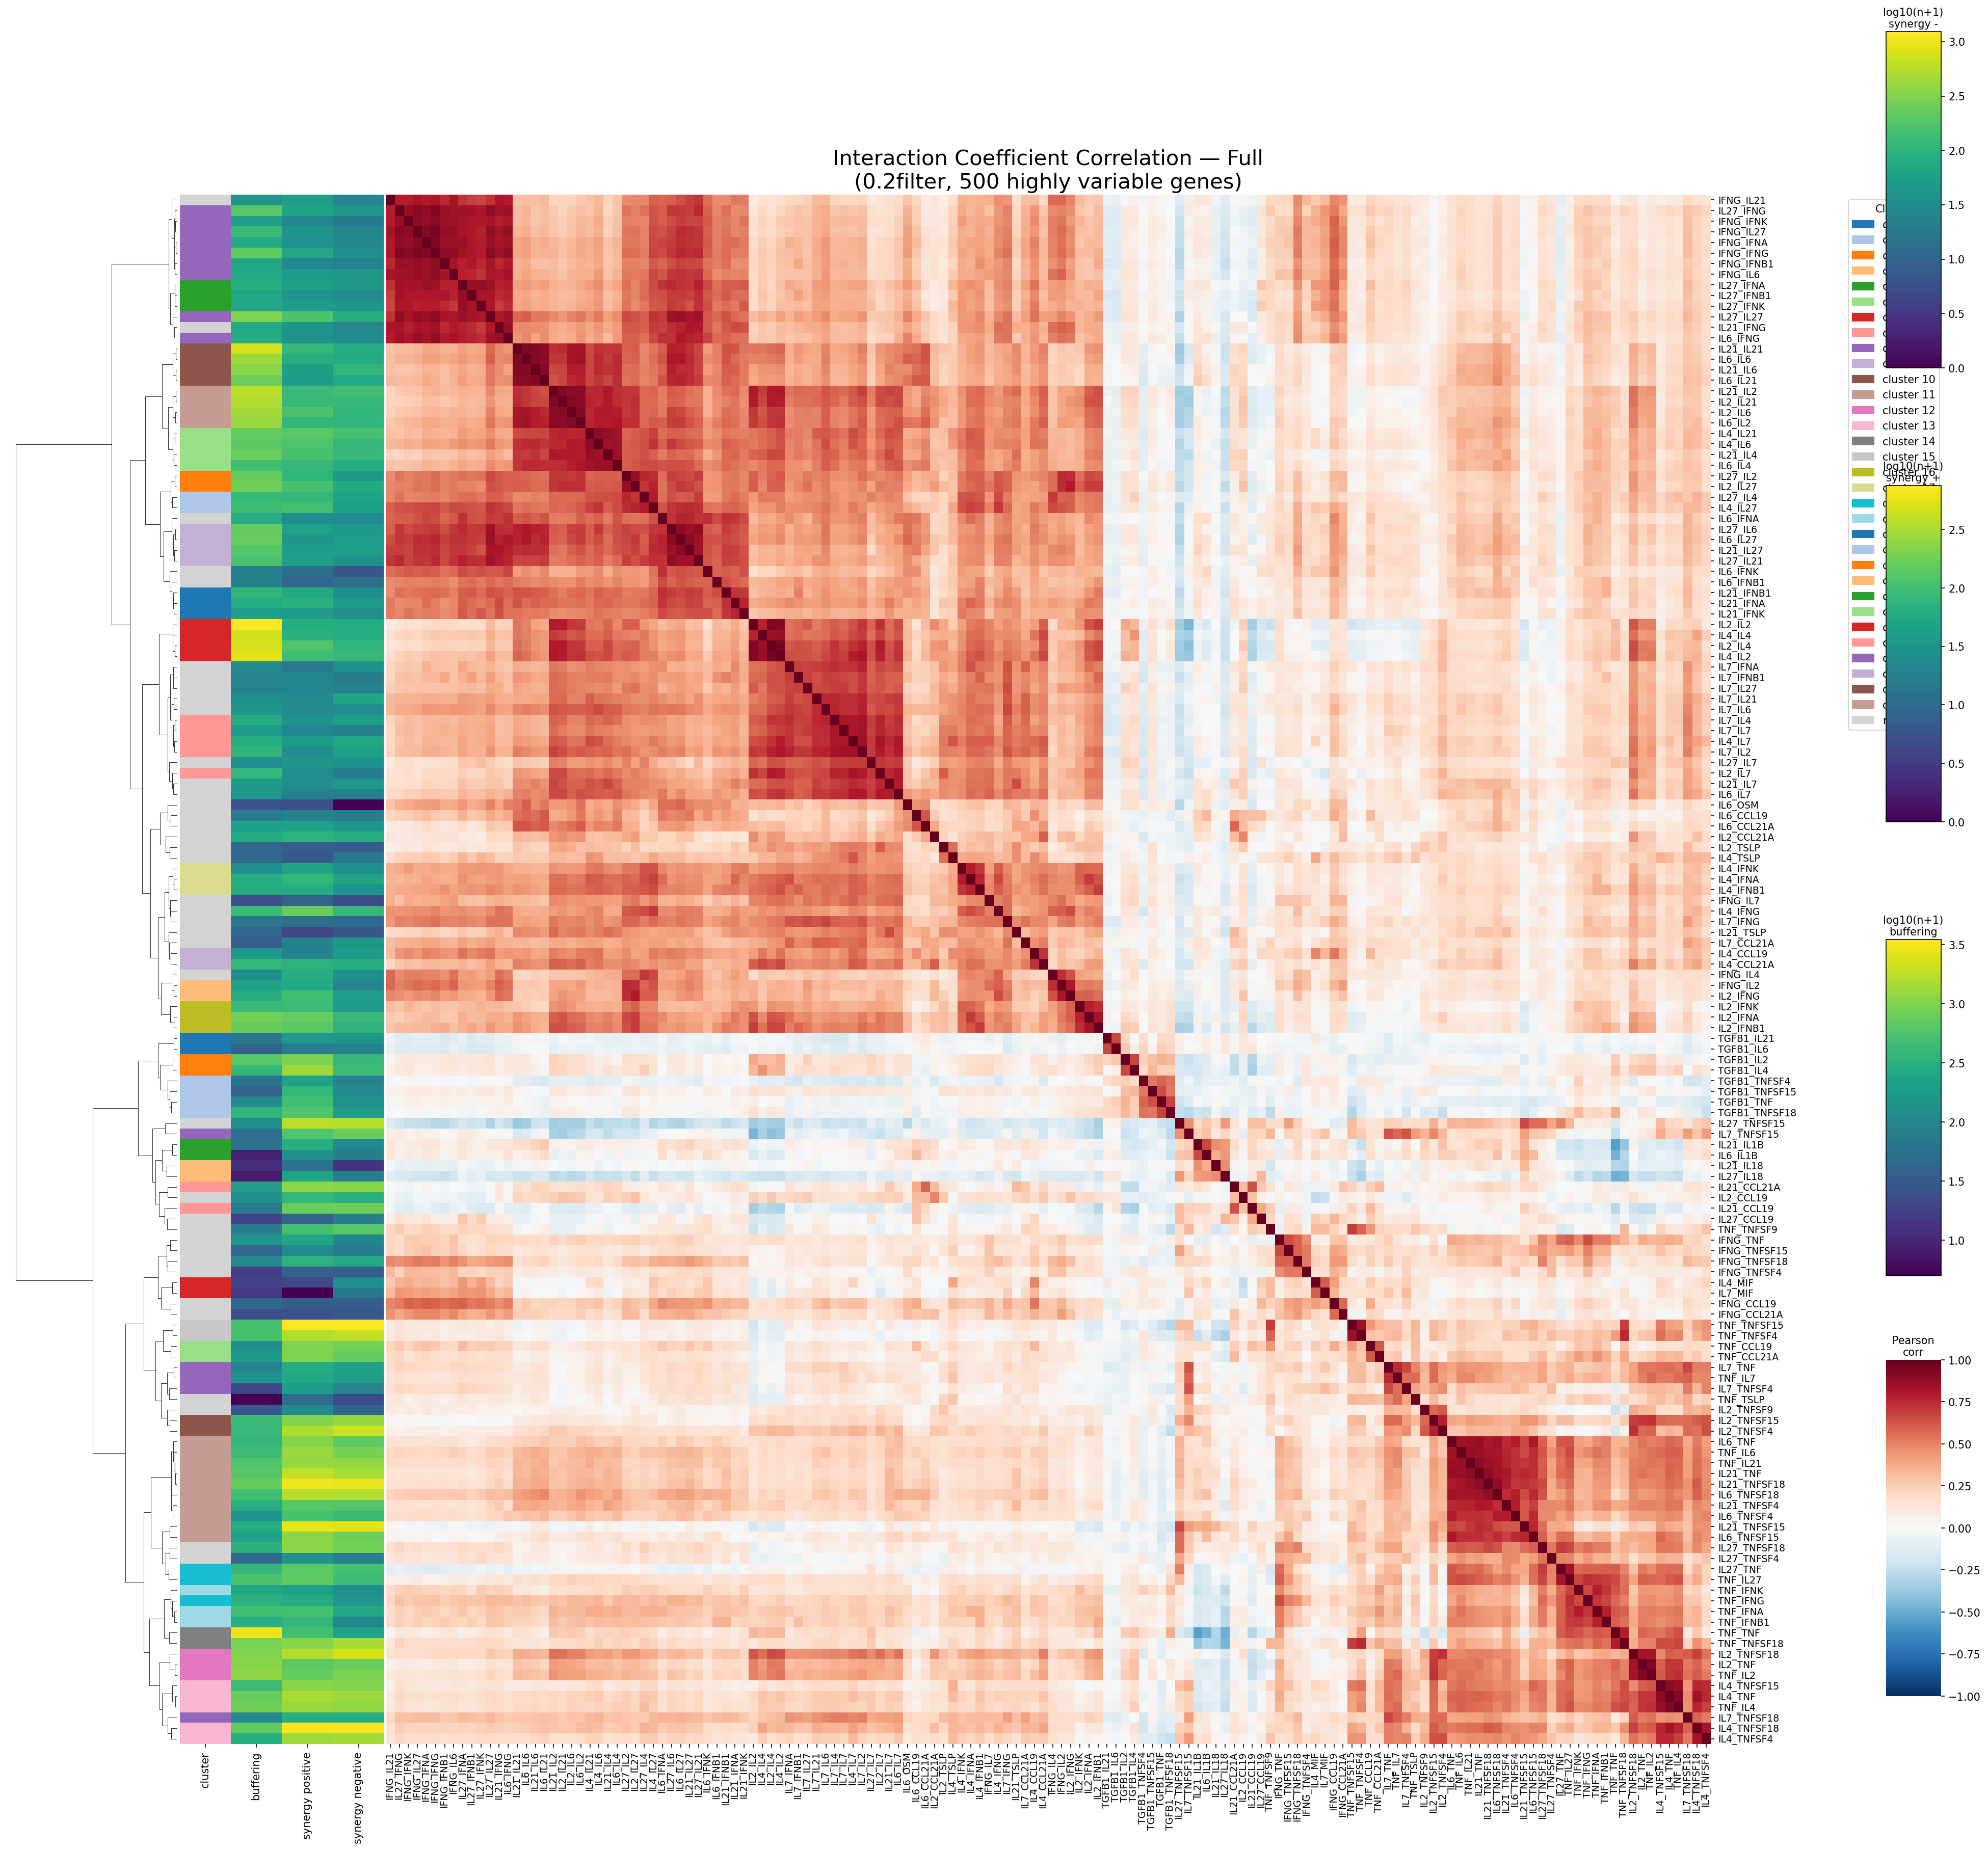

In [26]:
# Full heatmap: all consistent interactions, annotated by cluster (noise = grey) and by
# log10(n+1) significant interaction effects, split into buffering / synergy+ / synergy- classes
cluster_colors, legend_handles = build_cluster_row_colors(interaction_corr.index, interaction_clusters)

# Shared color range across buffering / synergy+ / synergy- so the three colorbars are comparable
class_count_series = [interaction_buffering_counts, interaction_synergy_pos_counts, interaction_synergy_neg_counts]
class_log10_values = np.concatenate([
    np.log10(s.reindex(interaction_corr.index).fillna(0).values + 1) for s in class_count_series
])
class_vmin, class_vmax = np.nanmin(class_log10_values), np.nanmax(class_log10_values)

buffering_colors, buffering_norm, buffering_cmap = build_numeric_row_colors(
    interaction_corr.index, interaction_buffering_counts, cmap='viridis', label='log10(n+1)\nbuffering',
    vmin=class_vmin, vmax=class_vmax
)
synergy_pos_colors, synergy_pos_norm, synergy_pos_cmap = build_numeric_row_colors(
    interaction_corr.index, interaction_synergy_pos_counts, cmap='viridis', label='log10(n+1)\nsynergy +',
    vmin=class_vmin, vmax=class_vmax
)
synergy_neg_colors, synergy_neg_norm, synergy_neg_cmap = build_numeric_row_colors(
    interaction_corr.index, interaction_synergy_neg_counts, cmap='viridis', label='log10(n+1)\nsynergy -',
    vmin=class_vmin, vmax=class_vmax
)
row_colors = pd.DataFrame({
    'cluster': cluster_colors,
    'buffering': buffering_colors,
    'synergy positive': synergy_pos_colors,
    'synergy negative': synergy_neg_colors,
})

plot_heatmap_anno(
    interaction_corr,
    row_colors=row_colors,
    legend_handles=legend_handles,
    numeric_cbars=[
        {'norm': buffering_norm, 'cmap': buffering_cmap, 'label': 'log10(n+1)\nbuffering'},
        {'norm': synergy_pos_norm, 'cmap': synergy_pos_cmap, 'label': 'log10(n+1)\nsynergy +'},
        {'norm': synergy_neg_norm, 'cmap': synergy_neg_cmap, 'label': 'log10(n+1)\nsynergy -'},
    ],
    title=f'Interaction Coefficient Correlation — Full\n({REF_FILTER}, {REF_N_GENES_INTERACTION} highly variable genes)',
    width=24, height=22,
    save_path=f'{plots_dir}/coefficient_corr_heatmap_interactions_full.pdf',
)

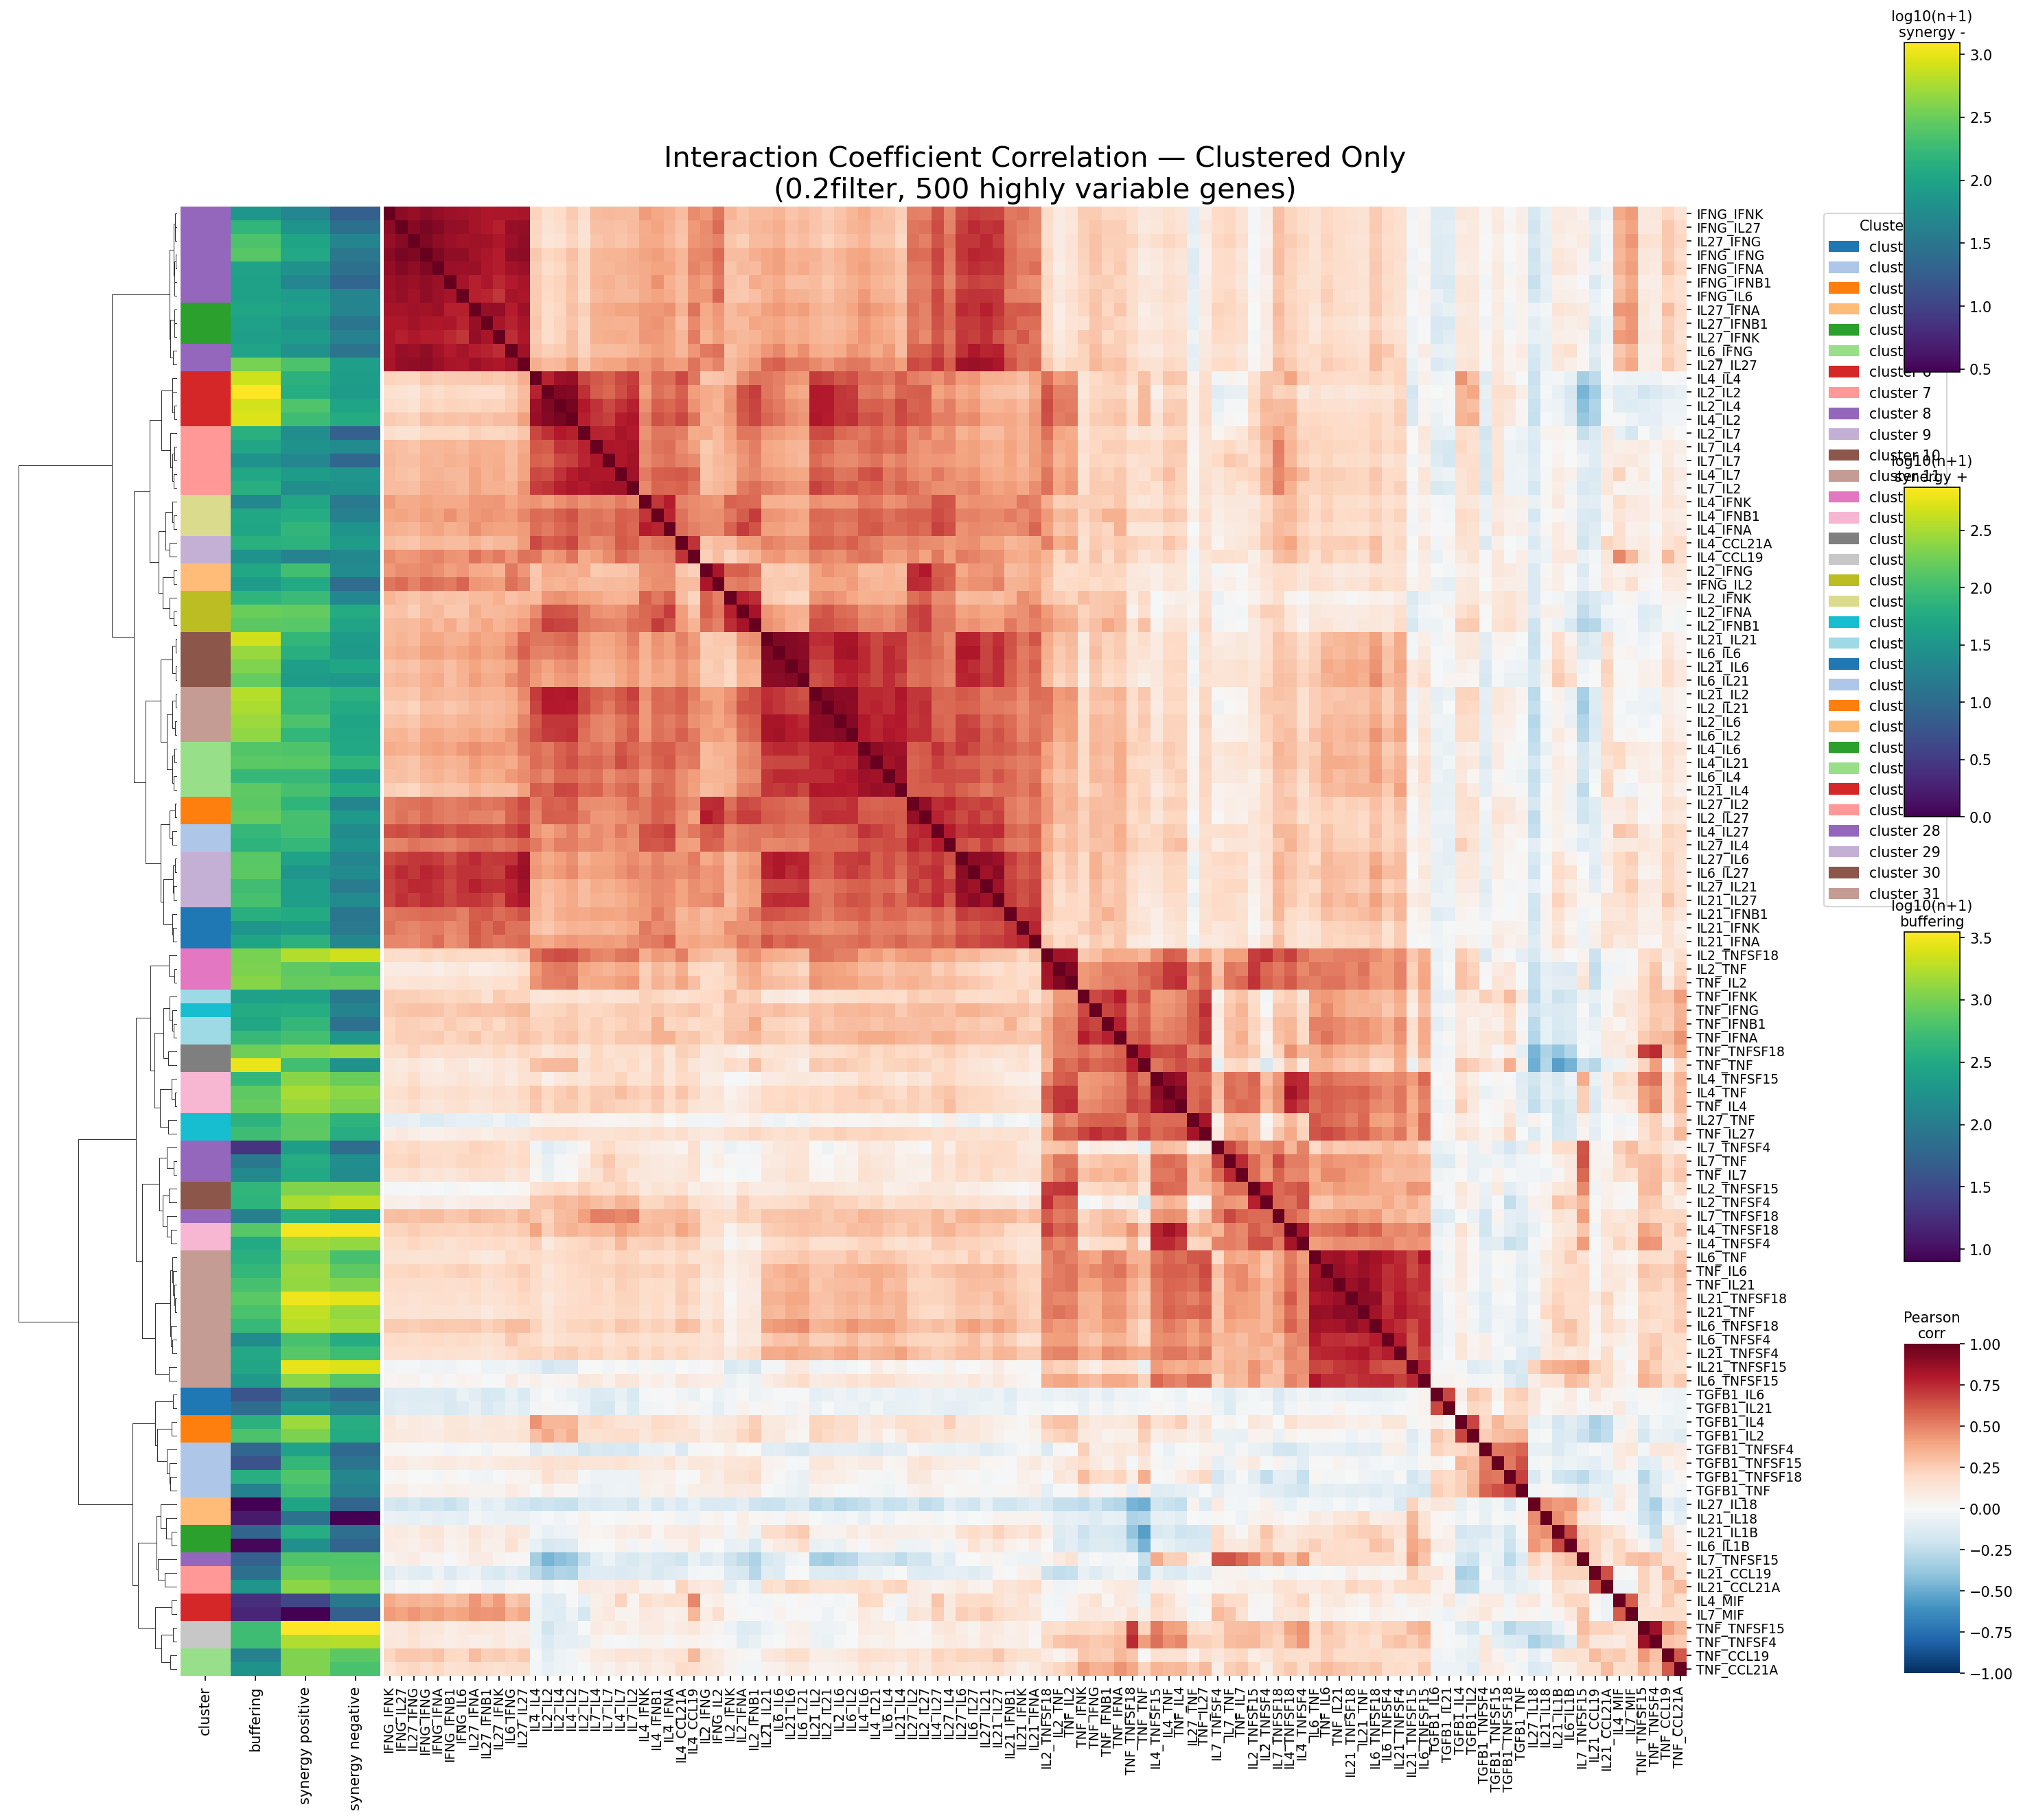

In [27]:
# Clustered-only heatmap: subset to interactions assigned to a real HDBSCAN cluster
clustered_interactions = interaction_clusters[interaction_clusters != -1].index
clustered_interactions = [i for i in clustered_interactions if i in interaction_corr.index]
interaction_corr_clustered = interaction_corr.loc[clustered_interactions, clustered_interactions]

cluster_colors_clustered, legend_handles_clustered = build_cluster_row_colors(
    interaction_corr_clustered.index, interaction_clusters
)

# Shared color range across buffering / synergy+ / synergy- so the three colorbars are comparable
class_count_series_clustered = [interaction_buffering_counts, interaction_synergy_pos_counts, interaction_synergy_neg_counts]
class_log10_values_clustered = np.concatenate([
    np.log10(s.reindex(interaction_corr_clustered.index).fillna(0).values + 1) for s in class_count_series_clustered
])
class_vmin_clustered, class_vmax_clustered = np.nanmin(class_log10_values_clustered), np.nanmax(class_log10_values_clustered)

buffering_colors_clustered, buffering_norm_clustered, buffering_cmap_clustered = build_numeric_row_colors(
    interaction_corr_clustered.index, interaction_buffering_counts, cmap='viridis', label='log10(n+1)\nbuffering',
    vmin=class_vmin_clustered, vmax=class_vmax_clustered
)
synergy_pos_colors_clustered, synergy_pos_norm_clustered, synergy_pos_cmap_clustered = build_numeric_row_colors(
    interaction_corr_clustered.index, interaction_synergy_pos_counts, cmap='viridis', label='log10(n+1)\nsynergy +',
    vmin=class_vmin_clustered, vmax=class_vmax_clustered
)
synergy_neg_colors_clustered, synergy_neg_norm_clustered, synergy_neg_cmap_clustered = build_numeric_row_colors(
    interaction_corr_clustered.index, interaction_synergy_neg_counts, cmap='viridis', label='log10(n+1)\nsynergy -',
    vmin=class_vmin_clustered, vmax=class_vmax_clustered
)
row_colors_clustered = pd.DataFrame({
    'cluster': cluster_colors_clustered,
    'buffering': buffering_colors_clustered,
    'synergy positive': synergy_pos_colors_clustered,
    'synergy negative': synergy_neg_colors_clustered,
})

plot_heatmap_anno(
    interaction_corr_clustered,
    row_colors=row_colors_clustered,
    legend_handles=legend_handles_clustered,
    numeric_cbars=[
        {'norm': buffering_norm_clustered, 'cmap': buffering_cmap_clustered, 'label': 'log10(n+1)\nbuffering'},
        {'norm': synergy_pos_norm_clustered, 'cmap': synergy_pos_cmap_clustered, 'label': 'log10(n+1)\nsynergy +'},
        {'norm': synergy_neg_norm_clustered, 'cmap': synergy_neg_cmap_clustered, 'label': 'log10(n+1)\nsynergy -'},
    ],
    title=f'Interaction Coefficient Correlation — Clustered Only\n({REF_FILTER}, {REF_N_GENES_INTERACTION} highly variable genes)',
    width=18, height=16,
    save_path=f'{plots_dir}/coefficient_corr_heatmap_interactions_clustered.pdf',
)

## Single Ligand Coefficient Correlation

In [28]:
single_wide_mat = build_wide_mat_single(single_coeff, single_sigLfc, REF_N_GENES_SINGLE, consistent_single_ligands)
single_corr = coeff_corr_matrix(single_wide_mat)
single_corr = single_corr.rename(index=rename_linker_condition, columns=rename_linker_condition)
print(f'Single-ligand correlation matrix: {single_corr.shape}')

Single-ligand correlation matrix: (38, 38)


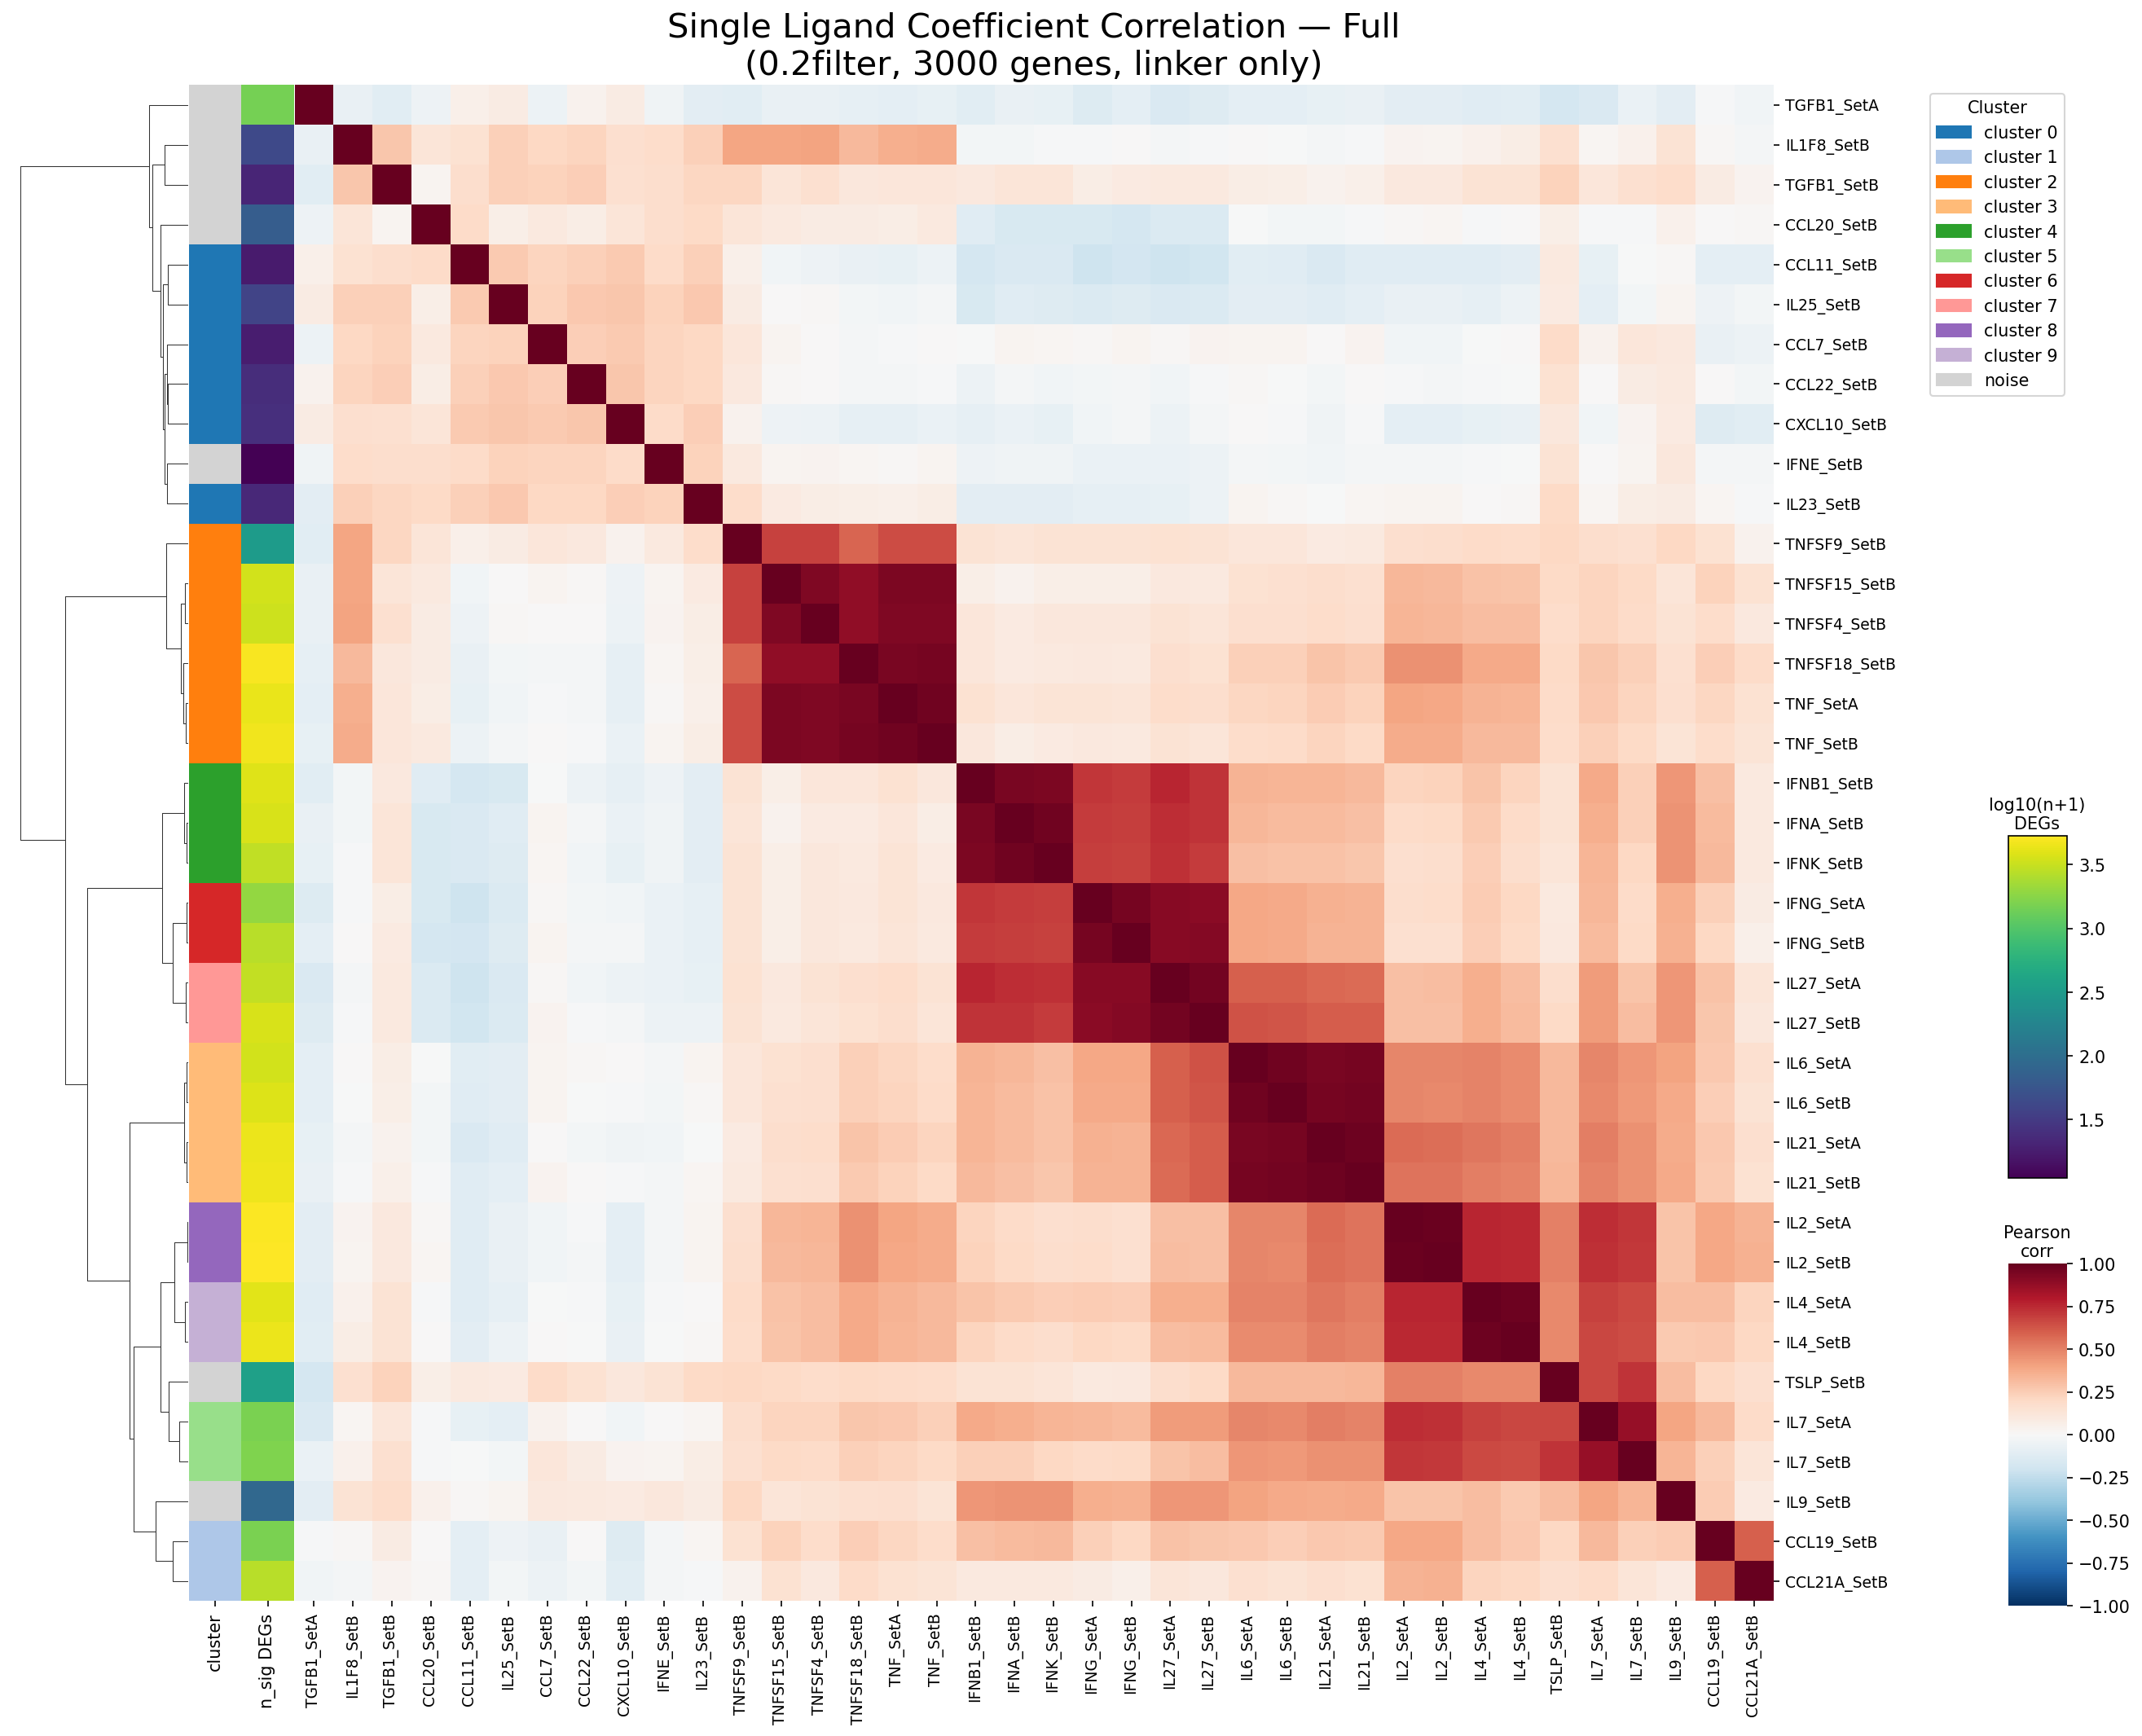

In [29]:
# Full heatmap: all linker-containing conditions, annotated by cluster (noise = grey) and
# by log10(n+1) significant DEGs (continuous)
cluster_colors, legend_handles = build_cluster_row_colors(single_corr.index, single_clusters)
n_deg_colors, n_deg_norm, n_deg_cmap = build_numeric_row_colors(
    single_corr.index, single_sig_counts, label='log10(n+1)\nDEGs'
)
row_colors = pd.DataFrame({'cluster': cluster_colors, 'n_sig DEGs': n_deg_colors})

plot_heatmap_anno(
    single_corr,
    row_colors=row_colors,
    legend_handles=legend_handles,
    numeric_cbars=[{'norm': n_deg_norm, 'cmap': n_deg_cmap, 'label': 'log10(n+1)\nDEGs'}],
    title=f'Single Ligand Coefficient Correlation — Full\n({REF_FILTER}, {REF_N_GENES_SINGLE} genes, linker only)',
    width=16, height=14,
    save_path=f'{plots_dir}/coefficient_corr_heatmap_singleLigand_full.pdf',
)

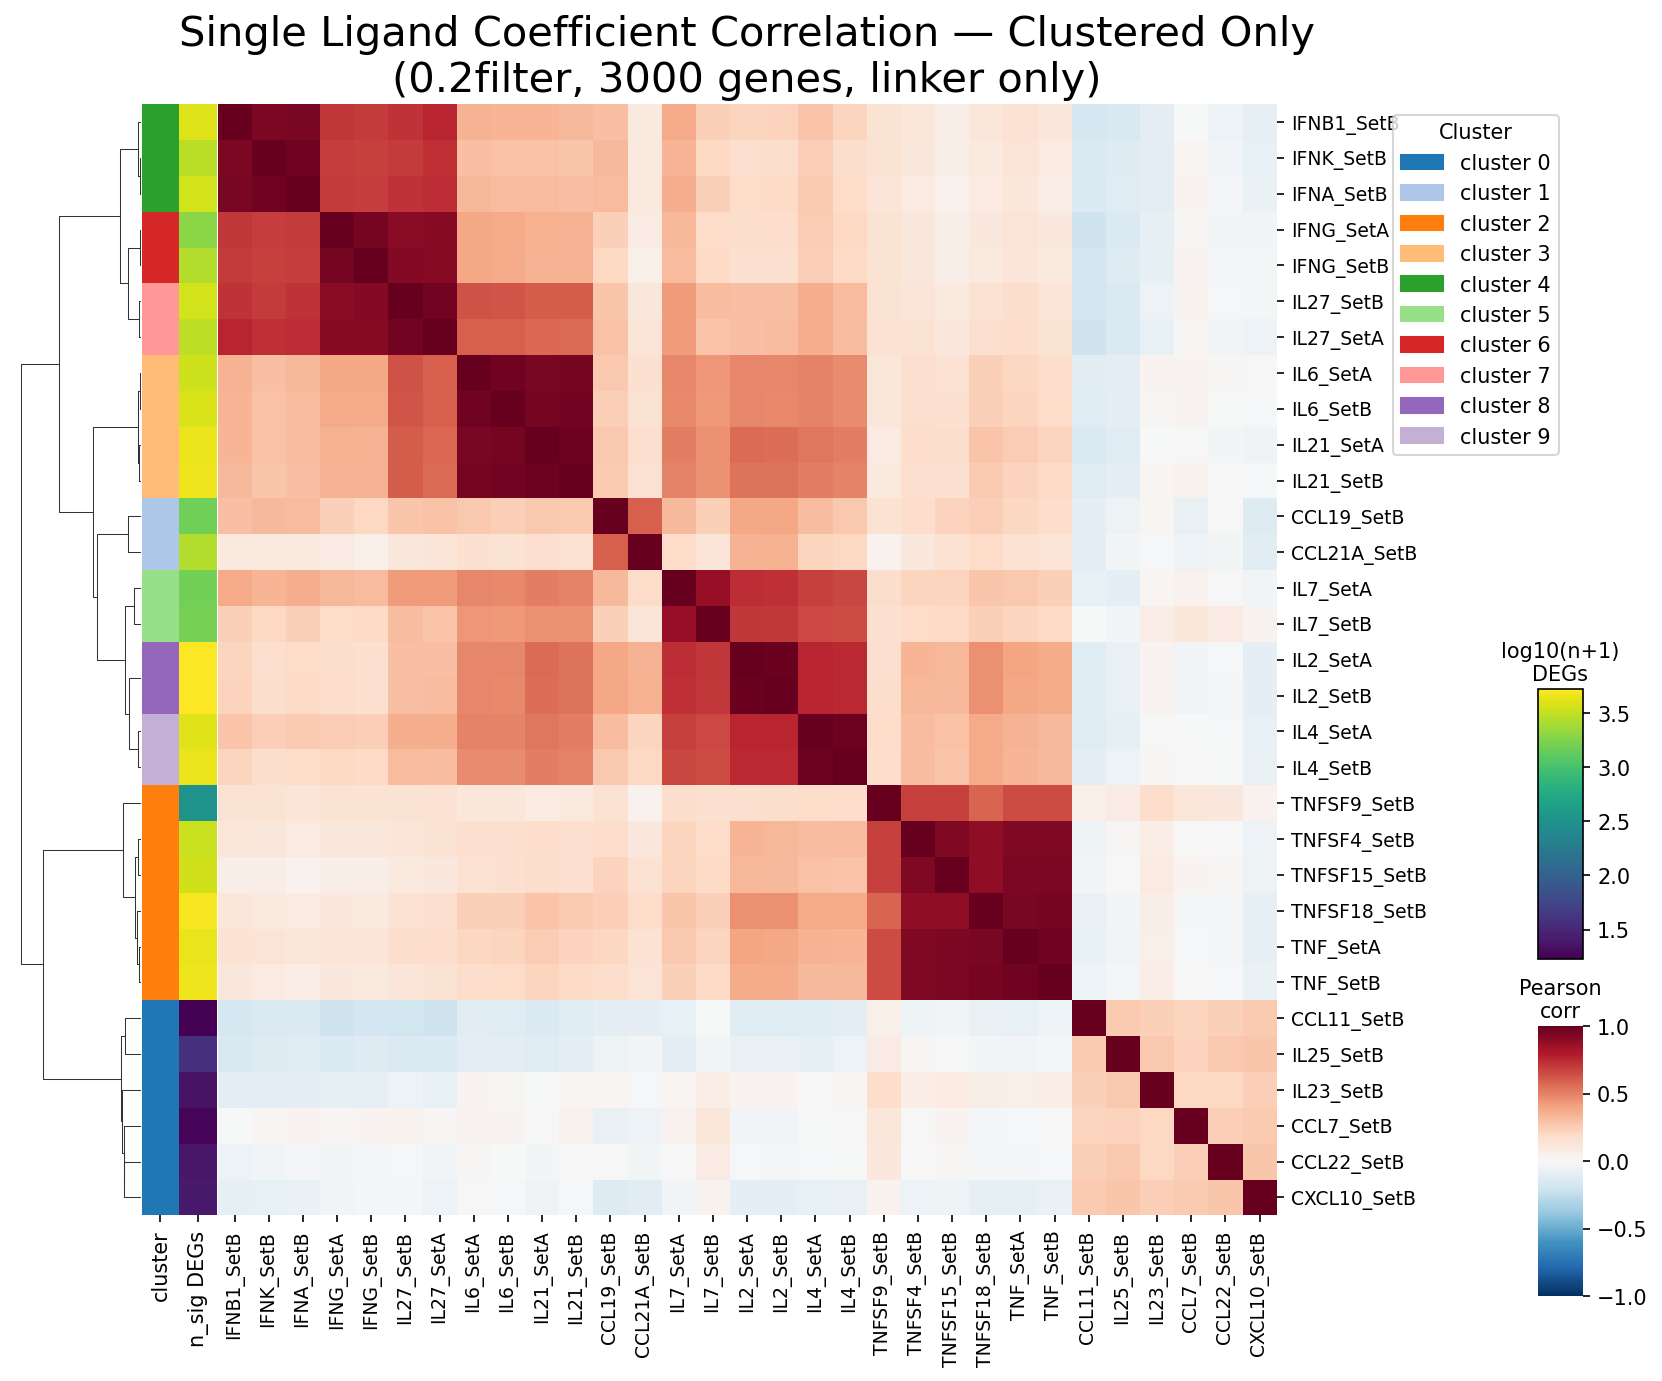

In [30]:
# Clustered-only heatmap: subset to conditions assigned to a real HDBSCAN cluster
clustered_conditions = single_clusters[single_clusters != -1].index
clustered_conditions = [c for c in clustered_conditions if c in single_corr.index]
single_corr_clustered = single_corr.loc[clustered_conditions, clustered_conditions]

cluster_colors_clustered, legend_handles_clustered = build_cluster_row_colors(
    single_corr_clustered.index, single_clusters
)
n_deg_colors_clustered, n_deg_norm_clustered, n_deg_cmap_clustered = build_numeric_row_colors(
    single_corr_clustered.index, single_sig_counts, label='log10(n+1)\nDEGs'
)
row_colors_clustered = pd.DataFrame({
    'cluster': cluster_colors_clustered,
    'n_sig DEGs': n_deg_colors_clustered,
})

plot_heatmap_anno(
    single_corr_clustered,
    row_colors=row_colors_clustered,
    legend_handles=legend_handles_clustered,
    numeric_cbars=[{'norm': n_deg_norm_clustered, 'cmap': n_deg_cmap_clustered, 'label': 'log10(n+1)\nDEGs'}],
    title=f'Single Ligand Coefficient Correlation — Clustered Only\n({REF_FILTER}, {REF_N_GENES_SINGLE} genes, linker only)',
    width=10, height=9,
    save_path=f'{plots_dir}/coefficient_corr_heatmap_singleLigand_clustered.pdf',
)